In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Imports Libraries and Tools

In [2]:
import os
import numpy as np
import random
from PIL import Image, ImageEnhance
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from sklearn.utils import shuffle


# Load Datasets

In [3]:
# Directories for training and testing data
train_dir = '/content/drive/MyDrive/MRI Images/Training/'
test_dir = '/content/drive/MyDrive/MRI Images/Testing/'

# Load and shuffle the train data
train_paths = []
train_labels = []
for label in os.listdir(train_dir):
    for image in os.listdir(os.path.join(train_dir, label)):
        train_paths.append(os.path.join(train_dir, label, image))
        train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)

# Load and shuffle the test data
test_paths = []
test_labels = []
for label in os.listdir(test_dir):
    for image in os.listdir(os.path.join(test_dir, label)):
        test_paths.append(os.path.join(test_dir, label, image))
        test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)

# Data Visualization

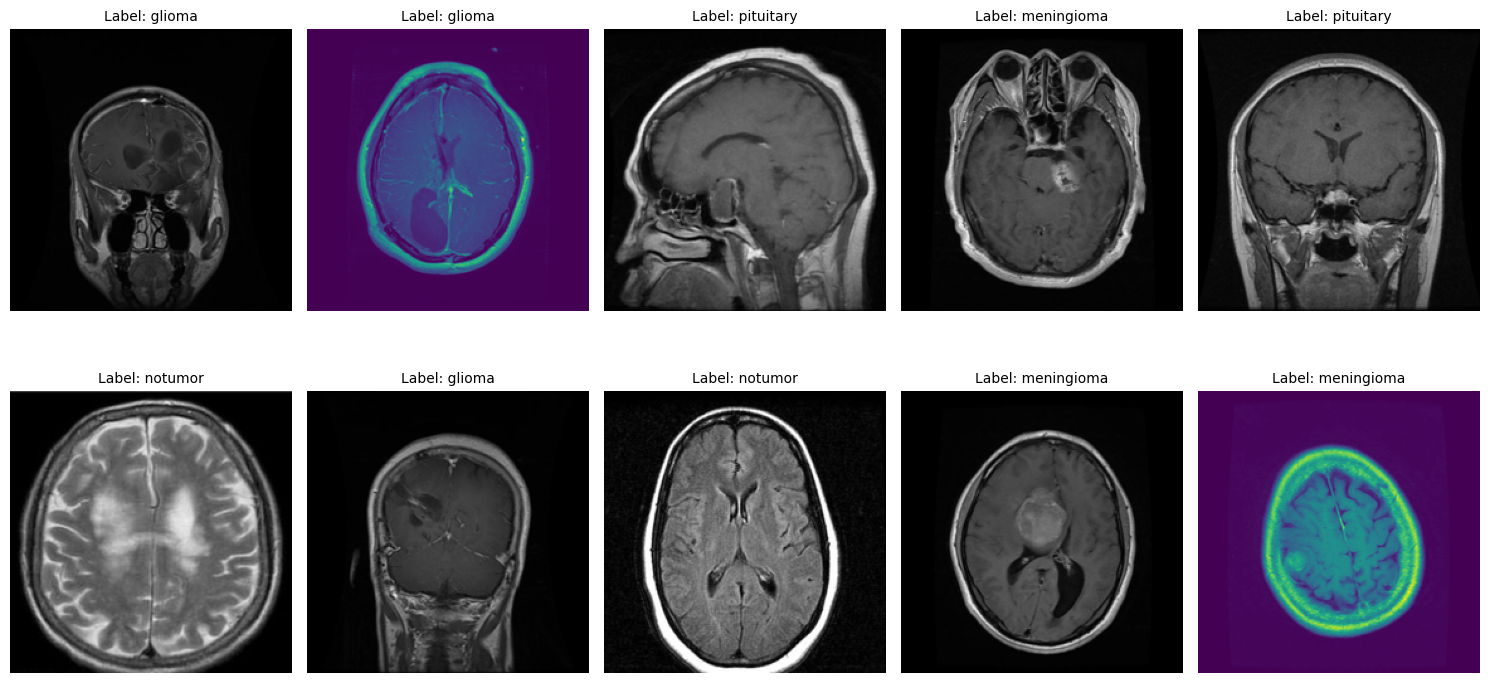

In [4]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import os

# Select random indices for 10 images
random_indices = random.sample(range(len(train_paths)), 10)

# Create a figure to display images in 2 rows
fig, axes = plt.subplots(2, 5, figsize=(15, 8))
axes = axes.ravel()

for i, idx in enumerate(random_indices):
    # Load image
    img_path = train_paths[idx]
    img = Image.open(img_path)
    img = img.resize((224, 224))  # Resize to consistent size

    # Display image
    axes[i].imshow(img)
    axes[i].axis('off')  # Hide axis
    # Display class label in the second row
    axes[i].set_title(f"Label: {train_labels[idx]}", fontsize=10)

plt.tight_layout()
plt.show()


# Image Preprocessing (Helper Functions)

In [5]:
# Image Augmentation function
def augment_image(image):
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))
    image = np.array(image) / 255.0
    return image

# Load images and apply augmentation
def open_images(paths):
    images = []
    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        image = augment_image(image)
        images.append(image)
    return np.array(images)

# Encoding labels (convert label names to integers)
def encode_label(labels):
    unique_labels = os.listdir(train_dir)
    encoded = [unique_labels.index(label) for label in labels]
    return np.array(encoded)

# Data generator for batching
def datagen(paths, labels, batch_size=12, epochs=1):
    for _ in range(epochs):
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i + batch_size]
            batch_images = open_images(batch_paths)
            batch_labels = labels[i:i + batch_size]
            batch_labels = encode_label(batch_labels)
            yield batch_images, batch_labels


# MODEL:

## WE ARE USING VGG16 FOR TRANSFER LEARNING.

 The model is built on top of VGG16, which is a pre-trained convolutional neural network (CNN) for image classification.

* First, the VGG16 model is loaded with input_shape=(IMAGE_SIZE,IMAGE_SIZE,3), include_top=False, weights='imagenet'. The input shape is set to match the size of the images in the dataset, which is 128x128 pixels. The include_top parameter is set to False, which means that the final fully-connected layers of VGG16 that perform the classification will not be included. The weights parameter is set to 'imagenet' which means that the model will be pre-trained with a dataset of 1.4 million images called imagenet

* Next, the for layer in base_model.layers: loop is used to set all layers of the base_model (VGG16) to non-trainable, so that the weights of these layers will not be updated during training.

* Then, the last three layers of the VGG16 model are set to trainable by using base_model.layers[-2].trainable = True,base_model.layers[-3].trainable = True and base_model.layers[-4].trainable = True

* After that, a Sequential model is created and the VGG16 model is added to it with model.add(base_model).

* Next, a Flatten layer is added to the model with model.add(Flatten()) which reshapes the output of the VGG16 model from a 3D tensor to a 1D tensor, so that it can be processed by the next layers of the model.

* Then, a Dropout layer is added with model.add(Dropout(0.3)) which is used to prevent overfitting by randomly setting a fraction of input units to 0 at each update during training time.

* After that, a dense layer is added with 128 neurons and relu activation function is added with model.add(Dense(128, activation='relu')).

* Next, another Dropout layer is added with model.add(Dropout(0.2))

* Finally, the output dense layer is added with number of neurons equal to the number of unique labels and 'softmax' activation function is added with model.add(Dense(len(unique_labels), activation='softmax')). The 'softmax' activation function is used to give a probability distribution over the possible classes.




In [7]:
# Model architecture
IMAGE_SIZE = 128
base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')

for layer in base_model.layers:
    layer.trainable = False

base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

model = Sequential()
model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))
model.add(base_model)
model.add(Flatten())
model.add(Dropout(0.3))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(len(os.listdir(train_dir)), activation='softmax'))

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['sparse_categorical_accuracy'])

batch_size = 20
steps = int(len(train_paths) / batch_size)
epochs = 6

history = model.fit(datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
                    epochs=epochs, steps_per_epoch=steps)


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/6
285/285 ━━━━━━━━━━━━━━━━━━━━ 1565s 5s/step - loss: 0.4589 - sparse_categorical_accuracy: 0.8221
Epoch 2/6
285/285 ━━━━━━━━━━━━━━━━━━━━ 41s 109ms/step - loss: 0.2349 - sparse_categorical_accuracy: 0.9153
Epoch 3/6
285/285 ━━━━━━━━━━━━━━━━━━━━ 31s 107ms/step - loss: 0.1553 - sparse_categorical_accuracy: 0.9413
Epoch 4/6
285/285 ━━━━━━━━━━━━━━━━━━━━ 31s 107ms/step - loss: 0.1110 - sparse_categorical_accuracy: 0.9580
Epoch 5/6
285/285 ━━━━━━━━━━━━━━━━━━━━ 31s 108ms/step - loss: 0.0919 - sparse_categorical_accuracy: 0.9659
Epoch 6/6
285/285 ━━━━━━━━━━━━━━━━━━━━ 31s 110ms/step - loss: 0.0672 - sparse_categorical_accuracy: 0.9773


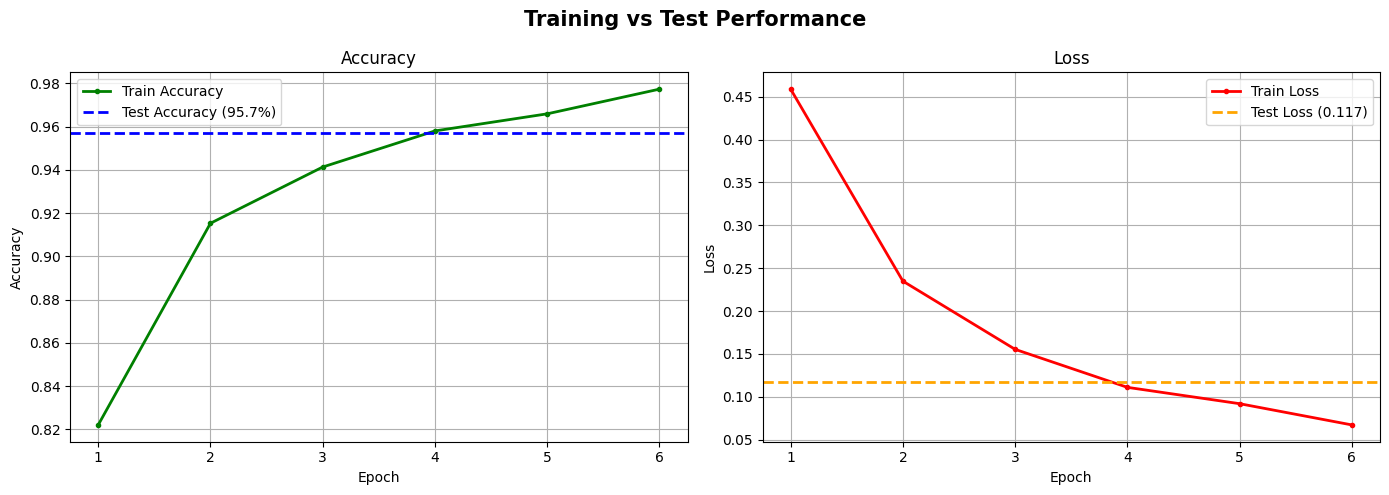

Final Train Accuracy : 97.73%
Final Train Loss     : 0.0672
Test  Accuracy       : 95.73%
Test  Loss           : 0.1167


In [8]:
import matplotlib.pyplot as plt
import numpy as np
IMAGE_SIZE = 128
# ── Evaluate model on test set ────────────────────────────────────────────────
test_images        = open_images(test_paths)
test_labels_enc    = encode_label(test_labels)

test_loss, test_acc = model.evaluate(test_images, test_labels_enc, verbose=0)
train_loss          = history.history['loss']
train_acc           = history.history['sparse_categorical_accuracy']

epoch_range = range(1, epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training vs Test Performance', fontsize=15, fontweight='bold')

# ── Accuracy plot ─────────────────────────────────────────────────────────────
axes[0].plot(epoch_range, train_acc, '.g-', linewidth=2, label='Train Accuracy')
axes[0].axhline(y=test_acc, color='blue', linestyle='--', linewidth=2, label=f'Test Accuracy ({test_acc*100:.1f}%)')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_xticks(epoch_range)
axes[0].legend()
axes[0].grid(True)

# ── Loss plot ─────────────────────────────────────────────────────────────────
axes[1].plot(epoch_range, train_loss, '.r-', linewidth=2, label='Train Loss')
axes[1].axhline(y=test_loss, color='orange', linestyle='--', linewidth=2, label=f'Test Loss ({test_loss:.3f})')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_xticks(epoch_range)
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"Final Train Accuracy : {train_acc[-1]*100:.2f}%")
print(f"Final Train Loss     : {train_loss[-1]:.4f}")
print(f"Test  Accuracy       : {test_acc*100:.2f}%")
print(f"Test  Loss           : {test_loss:.4f}")

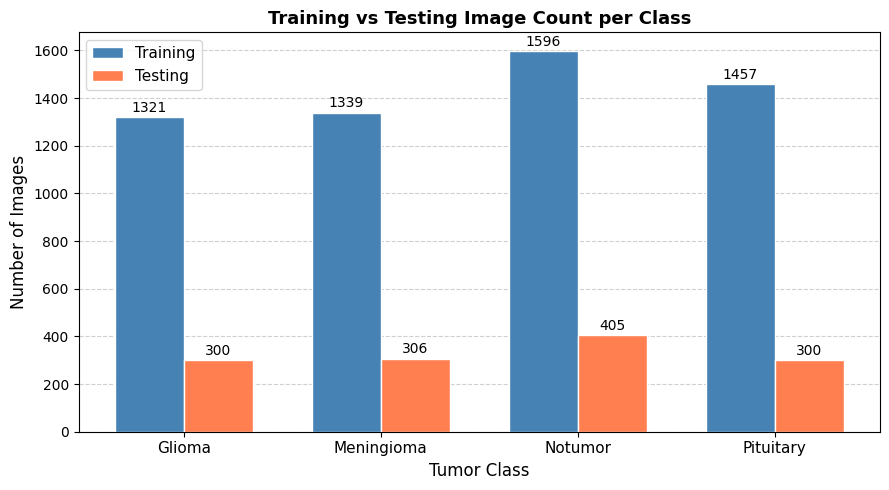

       Class   Train    Test   Total
------------------------------------
      Glioma    1321     300    1621
  Meningioma    1339     306    1645
     Notumor    1596     405    2001
   Pituitary    1457     300    1757
------------------------------------
       Total    5713    1311    7024


In [9]:
# ── Bar plot: Training vs Testing image counts per class ─────────────────────
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

train_counts = Counter(train_labels)
test_counts  = Counter(test_labels)
classes      = sorted(train_counts.keys())   # consistent order

train_vals = [train_counts[c] for c in classes]
test_vals  = [test_counts[c]  for c in classes]

x     = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars_train = ax.bar(x - width/2, train_vals, width, label='Training',
                    color='steelblue', edgecolor='white')
bars_test  = ax.bar(x + width/2, test_vals,  width, label='Testing',
                    color='coral',     edgecolor='white')

# Annotate counts on top of each bar
for bar in bars_train:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)
for bar in bars_test:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels([c.capitalize() for c in classes], fontsize=11)
ax.set_xlabel('Tumor Class', fontsize=12)
ax.set_ylabel('Number of Images', fontsize=12)
ax.set_title('Training vs Testing Image Count per Class', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

# Summary table
print(f'{'Class':>12}  {'Train':>6}  {'Test':>6}  {'Total':>6}')
print('-' * 36)
for c in classes:
    total = train_counts[c] + test_counts[c]
    print(f'{c.capitalize():>12}  {train_counts[c]:>6}  {test_counts[c]:>6}  {total:>6}')
print('-' * 36)
grand = sum(train_vals) + sum(test_vals)
print(f'{'Total':>12}  {sum(train_vals):>6}  {sum(test_vals):>6}  {grand:>6}')

# Train and Val Plots

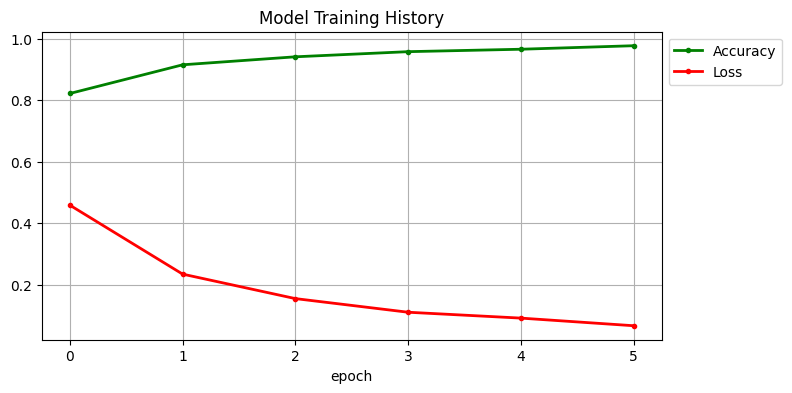

In [11]:
plt.figure(figsize=(8,4))
plt.grid(True)
plt.plot(history.history['sparse_categorical_accuracy'], '.g-', linewidth=2)
plt.plot(history.history['loss'], '.r-', linewidth=2)
plt.title('Model Training History')
plt.xlabel('epoch')
plt.xticks([x for x in range(epochs)])
plt.legend(['Accuracy', 'Loss'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

# Model Classification Report

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import load_model
import numpy as np

# 1. Prediction on test data
test_images = open_images(test_paths)  # Load and augment test images
test_labels_encoded = encode_label(test_labels)  # Encode the test labels

# Predict using the trained model
test_predictions = model.predict(test_images)

# 2. Classification Report
print("Classification Report:")
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1)))


41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       405
           1       1.00      0.98      0.99       300
           2       0.92      0.95      0.93       300
           3       0.94      0.91      0.92       306

    accuracy                           0.96      1311
   macro avg       0.96      0.96      0.96      1311
weighted avg       0.96      0.96      0.96      1311



# Model Confusion Plot

Confusion Matrix:
[[402   0   3   0]
 [  2 293   1   4]
 [  0   0 285  15]
 [  6   0  21 279]]


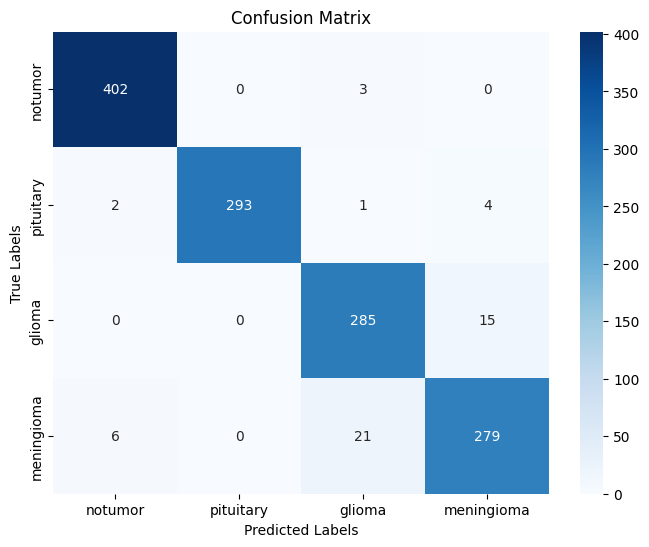

In [13]:
# 3. Confusion Matrix
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))
print("Confusion Matrix:")
print(conf_matrix)

# Plot the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=os.listdir(train_dir), yticklabels=os.listdir(train_dir))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Roc Curve Plot


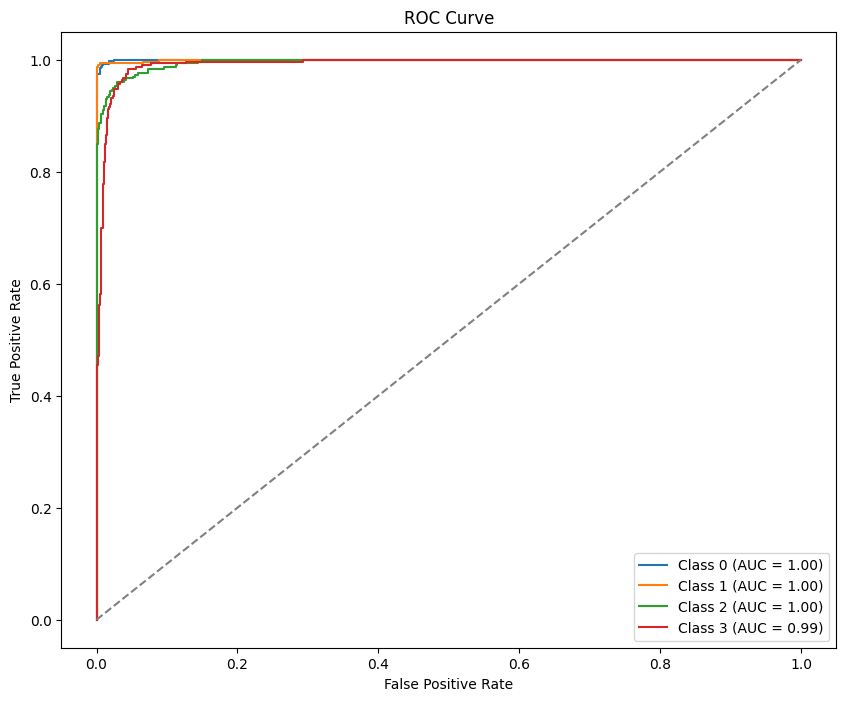

In [14]:
# 4. ROC Curve and AUC
# Binarize the test labels and predictions for multi-class ROC
test_labels_bin = label_binarize(test_labels_encoded, classes=np.arange(len(os.listdir(train_dir))))
test_predictions_bin = test_predictions  # The predicted probabilities for each class

# Compute ROC curve and ROC AUC for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(os.listdir(train_dir))):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], test_predictions_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve
plt.figure(figsize=(10, 8))
for i in range(len(os.listdir(train_dir))):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

# Save & Load Model

In [15]:
# Save the entire model
model.save('model.h5')

In [16]:
from tensorflow.keras.models import load_model
# Load the trained model
model = load_model('model.h5')

# MRI Tumor Detection System

In [17]:
from keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

# Build a stable label map from the SAME order used during training
unique_labels   = os.listdir(train_dir)          # same call encode_label() uses
INDEX_TO_LABEL  = {i: lbl for i, lbl in enumerate(unique_labels)}

def detect_and_display(img_path, model, image_size=128):
    """
    Function to detect tumor and display results.
    If no tumor is detected, it displays 'No Tumor Detected'.
    Otherwise, it shows the predicted tumor class and confidence.
    """
    try:
        # Load and preprocess — normalise the same way training did
        img       = load_img(img_path, target_size=(image_size, image_size))
        img_array = img_to_array(img) / 255.0      # matches augment_image()
        img_array = np.expand_dims(img_array, axis=0)

        # Predict
        probs         = model.predict(img_array, verbose=0)[0]
        predicted_idx = int(np.argmax(probs))
        predicted_cls = INDEX_TO_LABEL[predicted_idx]   # ✅ uses training order
        confidence    = probs[predicted_idx] * 100

        result = ('No Tumor Detected' if predicted_cls == 'notumor'
                  else f'Tumor: {predicted_cls.capitalize()}')
        color  = 'green' if predicted_cls == 'notumor' else 'red'

        plt.figure(figsize=(5, 5))
        plt.imshow(load_img(img_path))
        plt.axis('off')
        plt.title(f'{result}\nConfidence: {confidence:.2f}%', color=color, fontsize=13)
        plt.tight_layout()
        plt.show()

        print('Probabilities:')
        for idx, p in enumerate(probs):
            marker = ' ◀' if idx == predicted_idx else ''
            print(f'  {INDEX_TO_LABEL[idx]:12s}: {p*100:5.2f}%{marker}')

    except Exception as e:
        print('Error processing the image:', str(e))


##**Meingioma Predictions**

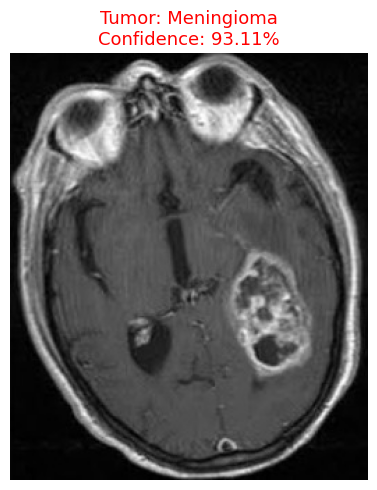

Probabilities:
  notumor     :  6.64%
  pituitary   :  0.15%
  glioma      :  0.10%
  meningioma  : 93.11% ◀


In [18]:
# Example usage
image_path = '/content/drive/MyDrive/MRI Images/Testing/meningioma/Te-meTr_0001.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

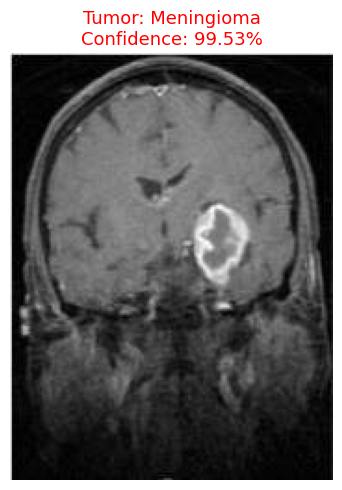

Probabilities:
  notumor     :  0.11%
  pituitary   :  0.25%
  glioma      :  0.11%
  meningioma  : 99.53% ◀


In [19]:
# Example usage
image_path = '/content/drive/MyDrive/MRI Images/Testing/meningioma/Te-me_0064.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

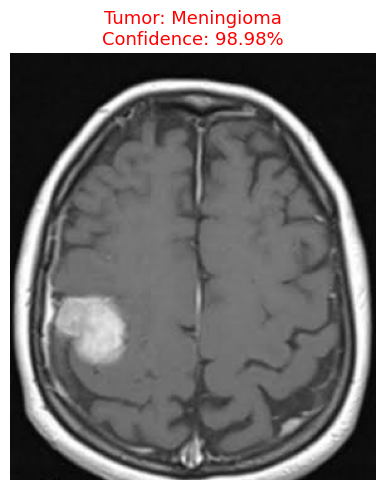

Probabilities:
  notumor     :  1.02%
  pituitary   :  0.00%
  glioma      :  0.00%
  meningioma  : 98.98% ◀


In [20]:
# Example usage
image_path = '/content/drive/MyDrive/MRI Images/Testing/meningioma/Te-me_0023.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

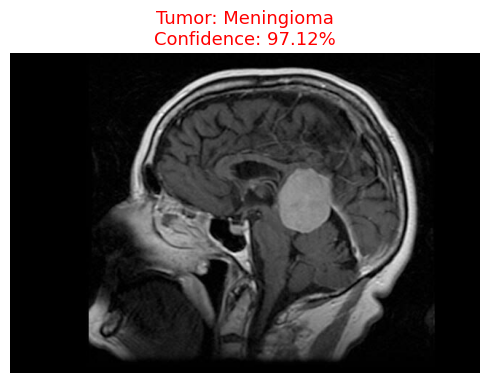

Probabilities:
  notumor     :  0.17%
  pituitary   :  0.08%
  glioma      :  2.63%
  meningioma  : 97.12% ◀


In [21]:
# Example usage
image_path = '/content/drive/MyDrive/MRI Images/Testing/meningioma/Te-me_0058.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

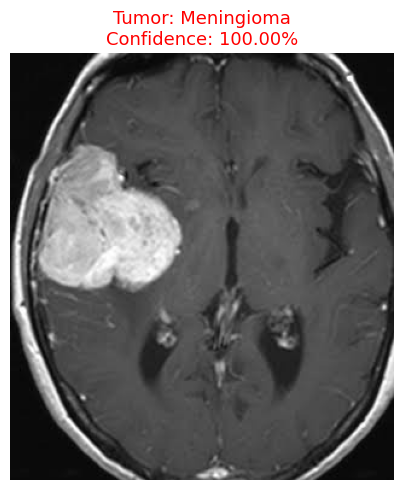

Probabilities:
  notumor     :  0.00%
  pituitary   :  0.00%
  glioma      :  0.00%
  meningioma  : 100.00% ◀


In [22]:
# Example usage
image_path = '/content/drive/MyDrive/MRI Images/Testing/meningioma/Te-me_0025.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

##**NoTumor Predictions**

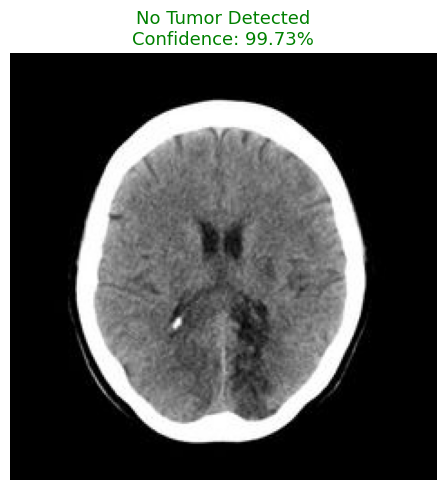

Probabilities:
  notumor     : 99.73% ◀
  pituitary   :  0.00%
  glioma      :  0.13%
  meningioma  :  0.14%


In [24]:
# Example usage
image_path = '/content/drive/MyDrive/MRI Images/Testing/notumor/Te-no_0055.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

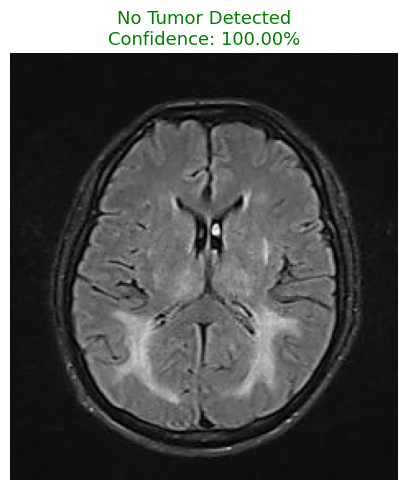

Probabilities:
  notumor     : 100.00% ◀
  pituitary   :  0.00%
  glioma      :  0.00%
  meningioma  :  0.00%


In [25]:
# Example usage
image_path = '/content/drive/MyDrive/MRI Images/Testing/notumor/Te-no_0067.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

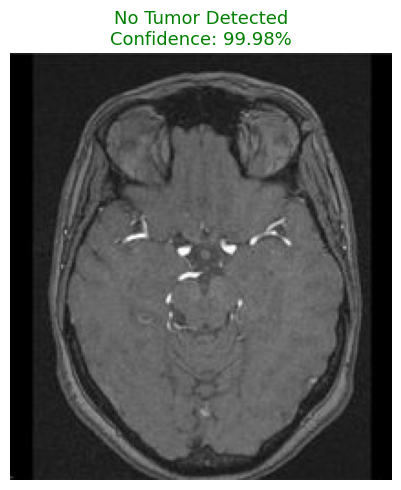

Probabilities:
  notumor     : 99.98% ◀
  pituitary   :  0.01%
  glioma      :  0.00%
  meningioma  :  0.01%


In [26]:
# Example usage
image_path = '/content/drive/MyDrive/MRI Images/Testing/notumor/Te-no_0024.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

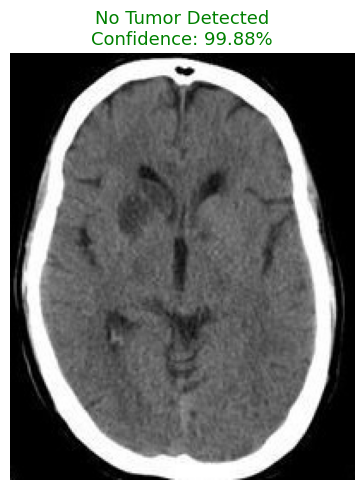

Probabilities:
  notumor     : 99.88% ◀
  pituitary   :  0.00%
  glioma      :  0.00%
  meningioma  :  0.11%


In [27]:
# Example usage
image_path = '/content/drive/MyDrive/MRI Images/Testing/notumor/Te-no_0034.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

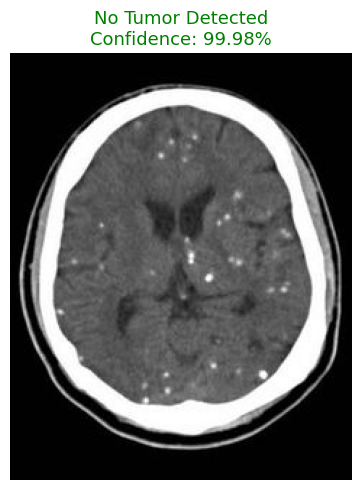

Probabilities:
  notumor     : 99.98% ◀
  pituitary   :  0.00%
  glioma      :  0.00%
  meningioma  :  0.02%


In [28]:
# Example usage
image_path = '/content/drive/MyDrive/MRI Images/Testing/notumor/Te-no_0086.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

##**Pituitary Predictions**

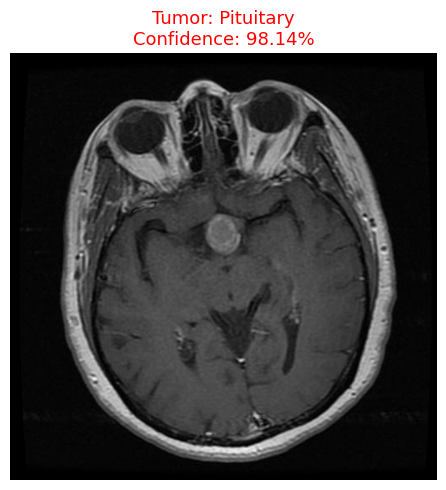

Probabilities:
  notumor     :  0.36%
  pituitary   : 98.14% ◀
  glioma      :  0.00%
  meningioma  :  1.50%


In [29]:
# Example usage
image_path = '/content/drive/MyDrive/MRI Images/Testing/pituitary/Te-pi_0015.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

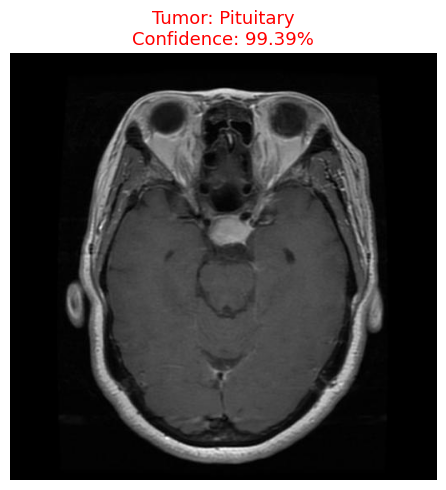

Probabilities:
  notumor     :  0.01%
  pituitary   : 99.39% ◀
  glioma      :  0.00%
  meningioma  :  0.60%


In [30]:
# Example usage
image_path = '/content/drive/MyDrive/MRI Images/Testing/pituitary/Te-pi_0072.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

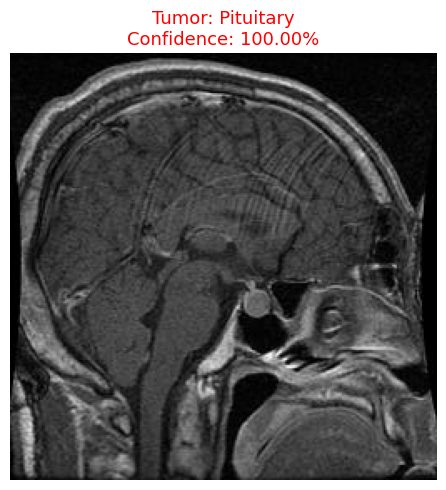

Probabilities:
  notumor     :  0.00%
  pituitary   : 100.00% ◀
  glioma      :  0.00%
  meningioma  :  0.00%


In [31]:
# Example usage
image_path = '/content/drive/MyDrive/MRI Images/Testing/pituitary/Te-pi_0099.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

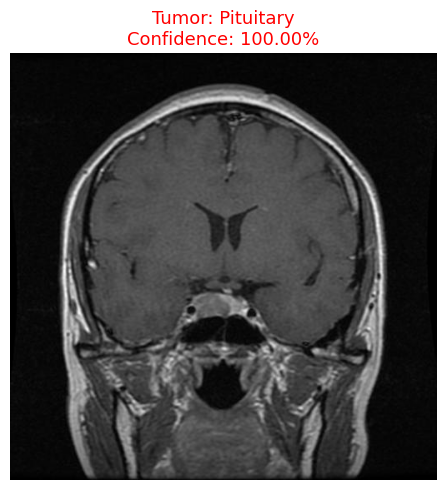

Probabilities:
  notumor     :  0.00%
  pituitary   : 100.00% ◀
  glioma      :  0.00%
  meningioma  :  0.00%


In [32]:
# Example usage
image_path = '/content/drive/MyDrive/MRI Images/Testing/pituitary/Te-pi_0199.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

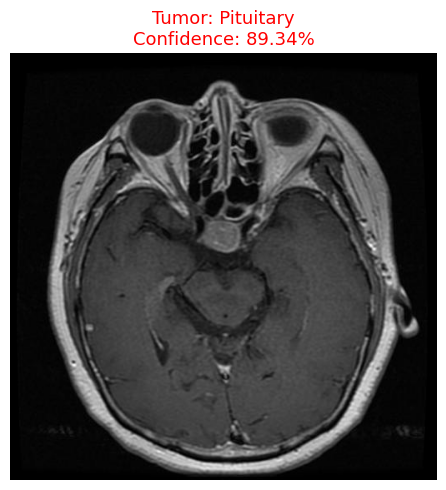

Probabilities:
  notumor     :  0.57%
  pituitary   : 89.34% ◀
  glioma      :  0.00%
  meningioma  : 10.09%


In [33]:
# Example usage
image_path = '/content/drive/MyDrive/MRI Images/Testing/pituitary/Te-pi_0139.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

##**Glioma Predictions**

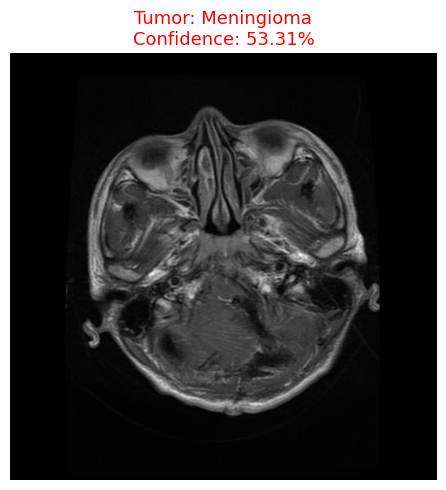

Probabilities:
  notumor     :  2.76%
  pituitary   :  0.36%
  glioma      : 43.57%
  meningioma  : 53.31% ◀


In [34]:
# Example usage
image_path = '/content/drive/MyDrive/MRI Images/Testing/glioma/Te-gl_0024.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

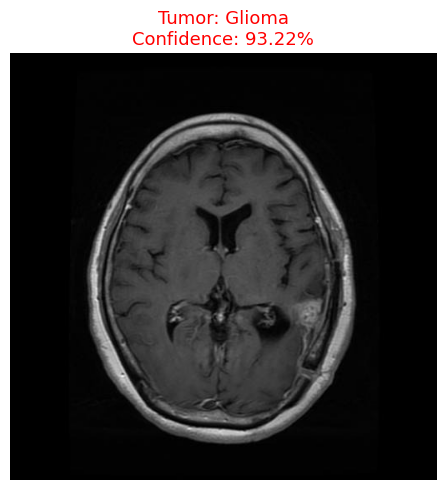

Probabilities:
  notumor     :  0.37%
  pituitary   :  0.09%
  glioma      : 93.22% ◀
  meningioma  :  6.32%


In [35]:
# Example usage
image_path = '/content/drive/MyDrive/MRI Images/Testing/glioma/Te-gl_0019.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

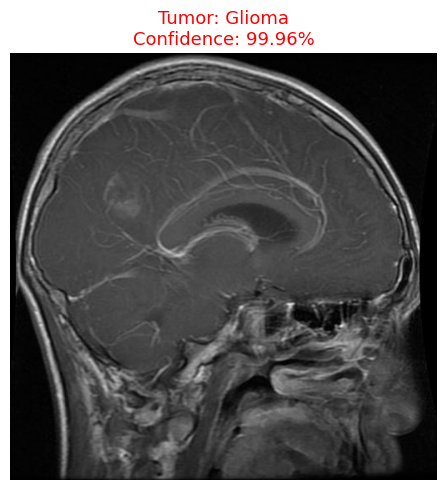

Probabilities:
  notumor     :  0.00%
  pituitary   :  0.03%
  glioma      : 99.96% ◀
  meningioma  :  0.00%


In [36]:
# Example usage
image_path = '/content/drive/MyDrive/MRI Images/Testing/glioma/Te-gl_0226.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

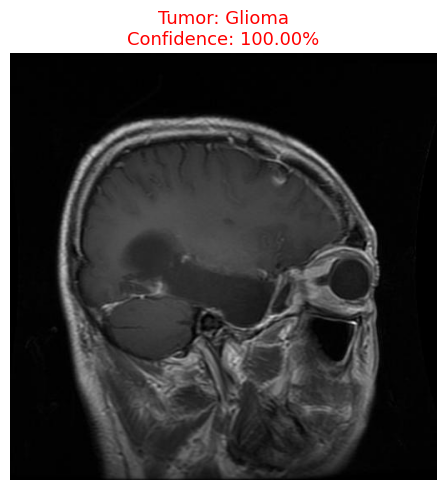

Probabilities:
  notumor     :  0.00%
  pituitary   :  0.00%
  glioma      : 100.00% ◀
  meningioma  :  0.00%


In [37]:
# Example usage
image_path = '/content/drive/MyDrive/MRI Images/Testing/glioma/Te-gl_0161.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

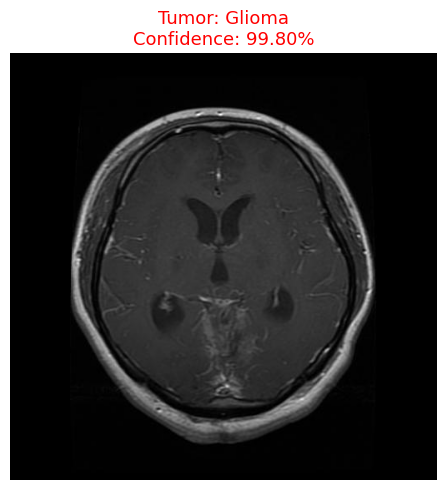

Probabilities:
  notumor     :  0.07%
  pituitary   :  0.02%
  glioma      : 99.80% ◀
  meningioma  :  0.12%


In [38]:
# Example usage
image_path = '/content/drive/MyDrive/MRI Images/Testing/glioma/Te-gl_0111.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)